# Correlating stock index performance with macroeconomic indicators using Regression

The target variables are: 
- Target (Y): daily change percentage 
- Predictors (X): GDP growth, inflation, interest rate, unemployment

Authors: Lohane da Cruz Evora and Irena Nguyen (NGUYEN THI HONG HAI)

## Install library

This project uses the following libraries:
- numpy
- pandas
...

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math
# For prediction
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# note! [delete later!]: ModuleNotFoundError when importing the libraries --> view >> terminal >> pip install numpy pandas matplotlib seaborn scikit-learn kagglehub

## Dataset

### Introducing the dataset

This dataset contains information on global stock markets and macroeconomic indicators for 39 countries as of 2024-08-15. It covers countries across North America, Europe, Asia, including both developed (US, Japan, Germany, UK) and emerging economies (China, India, Brazil, etc.).

#### Key Features:
- Market Data: Country, stock index name, index value, daily change %.

- Economic Indicators: GDP growth rate, inflation, interest rates, unemployment.

- Others features: 
    - Financial Market Metrics: Market capitalization, bond yields, credit rating.
    - Commodities & Assets: Oil price, gold price, commodity index.
    - Risk & Stability: Political risk score, banking sector health, real estate index.
    - Trade & Growth: Export and import growth percentages.
- For the purpose of this project, only the features regarding the market as well as the economic indicators are included for the study.

In [23]:
# Importing dataset
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("imaadmahmood/global-finance-and-economic-indicators-dataset-2024")

files = os.listdir(path)
print(files)

file_path = os.path.join(path, files[0])  # take first file
df = pd.read_csv(file_path)

df.head()

['Global finance data.csv']


,Country,Date,Stock_Index,Index_Value,Daily_Change_Percent,Market_Cap_Trillion_USD,GDP_Growth_Rate_Percent,Inflation_Rate_Percent,Interest_Rate_Percent,Unemployment_Rate_Percent,...,Commodity_Index,Oil_Price_USD_Barrel,Gold_Price_USD_Ounce,Bond_Yield_10Y_Percent,Credit_Rating,Political_Risk_Score,Banking_Sector_Health,Real_Estate_Index,Export_Growth_Percent,Import_Growth_Percent
0,United States,2024-08-15,S&P_500,5437.2,0.34,51.2,2.8,2.9,5.50,3.7,...,1.12,77.85,2487.5,4.25,AAA,8.1,Strong,145.6,3.2,2.8
1,China,2024-08-15,Shanghai_Composite,2891.6,-0.82,12.4,5.2,0.8,3.10,5.2,...,0.98,77.85,2487.5,2.15,A+,6.7,Moderate,98.7,8.9,6.1
2,Japan,2024-08-15,Nikkei_225,36789.1,1.24,6.8,0.9,2.8,-0.10,2.4,...,1.05,77.85,2487.5,0.89,A+,8.4,Strong,89.3,5.1,4.7
3,Germany,2024-08-15,DAX,18234.5,0.67,2.9,0.3,2.2,4.50,3.1,...,1.08,77.85,2487.5,2.31,AAA,8.7,Strong,112.4,2.1,1.8
4,United Kingdom,2024-08-15,FTSE_100,8156.3,-0.15,3.1,1.1,2.0,5.25,4.2,...,1.06,77.85,2487.5,3.89,AA,7.9,Moderate,97.8,0.9,1.2


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 26 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              39 non-null     str    
 1   Date                                 39 non-null     str    
 2   Stock_Index                          39 non-null     str    
 3   Index_Value                          39 non-null     float64
 4   Daily_Change_Percent                 39 non-null     float64
 5   Market_Cap_Trillion_USD              39 non-null     float64
 6   GDP_Growth_Rate_Percent              39 non-null     float64
 7   Inflation_Rate_Percent               39 non-null     float64
 8   Interest_Rate_Percent                39 non-null     float64
 9   Unemployment_Rate_Percent            39 non-null     float64
 10  Currency_Code                        39 non-null     str    
 11  Exchange_Rate_USD                    39 non-n

In [25]:
col = [
    "Country",
    "GDP_Growth_Rate_Percent",
    "Inflation_Rate_Percent",
    "Interest_Rate_Percent",
    "Unemployment_Rate_Percent",
    "Daily_Change_Percent"
]

target = "Daily_Change_Percent"

df = df[col]

df.head()

,Country,GDP_Growth_Rate_Percent,Inflation_Rate_Percent,Interest_Rate_Percent,Unemployment_Rate_Percent,Daily_Change_Percent
0,United States,2.8,2.9,5.50,3.7,0.34
1,China,5.2,0.8,3.10,5.2,-0.82
2,Japan,0.9,2.8,-0.10,2.4,1.24
3,Germany,0.3,2.2,4.50,3.1,0.67
4,United Kingdom,1.1,2.0,5.25,4.2,-0.15


In [26]:
# df's info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    39 non-null     str    
 1   GDP_Growth_Rate_Percent    39 non-null     float64
 2   Inflation_Rate_Percent     39 non-null     float64
 3   Interest_Rate_Percent      39 non-null     float64
 4   Unemployment_Rate_Percent  39 non-null     float64
 5   Daily_Change_Percent       39 non-null     float64
dtypes: float64(5), str(1)
memory usage: 2.0 KB


### Data prepocessing

In [27]:
# Checking for missing values
df_na = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Duplicate": df.duplicated().sum()
})

df_na # No 

,Missing Values,Duplicate
Country,0,0
GDP_Growth_Rate_Percent,0,0
Inflation_Rate_Percent,0,0
Interest_Rate_Percent,0,0
Unemployment_Rate_Percent,0,0
Daily_Change_Percent,0,0


## Analysis

### Exploratory Data Analysis

In [28]:
# Descriptive statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
GDP_Growth_Rate_Percent,39.0,2.415385,1.874558,-1.90,1.15,2.40,3.15,6.80
Inflation_Rate_Percent,39.0,11.023077,34.828629,-0.40,1.95,2.80,4.30,211.40
Interest_Rate_Percent,39.0,10.643590,21.866714,-0.10,4.05,4.75,6.50,133.00
Unemployment_Rate_Percent,39.0,5.887179,4.636138,1.20,3.30,5.10,7.30,28.70
Daily_Change_Percent,39.0,0.654103,0.834672,-1.23,0.31,0.67,0.89,3.45


#### Intepretation
1. GDP_Growth_Rate_Percent
Mean =~ 2.42% -> moderate growth on average
Range: -1.90 to 6.80 -> some country has negative growth
Std = 1.87 -> fairly stable compared to others
2. Inflation_Rate_Percent
Mean ≈ 11.02% -> already high
Min = 0.40%
Max = 211.40% 
Std ≈ 34.83  -> very large
-> This column has extreme outliers (hyperinflation in some of the observed countries), the mean is therefore misleading due to those countries.
3. Interest_Rate_Percent
Mean ≈ 10.64%
Max = 133.00%
Std ≈ 21.87
-> Same problem with the previous one.
4. Unemployment_Rate_Percent
Mean ≈ 5.89%
Range: 1.20 – 28.70
Std ≈ 4.64
-> Same problem with the previous one.
5. Daily_Change_Percent (target)
Mean ≈ 0.65%
Range: -1.23 to 3.45
Std ≈ 0.83
-> Small daily fluctuations as expected for financial data. The data has a fairly tight distribution, which is good for modeling.

In [114]:
extreme = []
variables = [
    "GDP_Growth_Rate_Percent",
    "Inflation_Rate_Percent",
    "Interest_Rate_Percent",
    "Unemployment_Rate_Percent",
    "Daily_Change_Percent"
]

for var in variables:
    # index of min and max
    min_idx = df[var].idxmin()
    max_idx = df[var].idxmax()
    
    extreme.append({
        "Variable": var,
        "Min Value": df.loc[min_idx, var],
        "Min Country": df.loc[min_idx, "Country"],
        "Max Value": df.loc[max_idx, var],
        "Max Country": df.loc[max_idx, "Country"]
    })

extremes_df = pd.DataFrame(extreme)
extremes_df

,Variable,Min Value,Min Country,Max Value,Max Country
0,GDP_Growth_Rate_Percent,-1.900000,Russia,6.800000,India
1,Inflation_Rate_Percent,-0.715036,Saudi Arabia,1.849788,Argentina
2,Interest_Rate_Percent,-0.111334,Japan,1.774586,Argentina
3,Unemployment_Rate_Percent,1.200000,Thailand,28.700000,South Africa
4,Daily_Change_Percent,-1.230000,Hong Kong,3.450000,Argentina


##### Key insights
- Big issues with outliners for Inflation and Interest Rate
- Variables in different scales -> inneed of scaling
- Target variable looks well-behaved

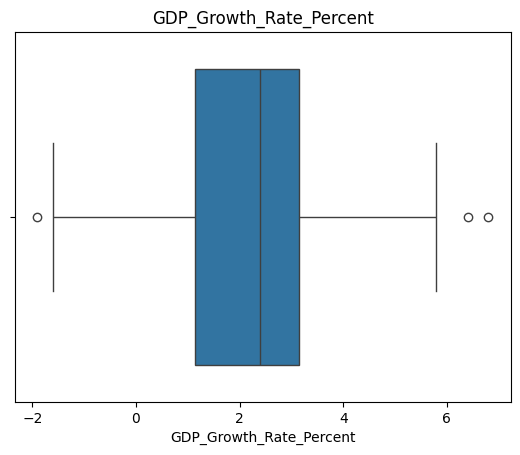

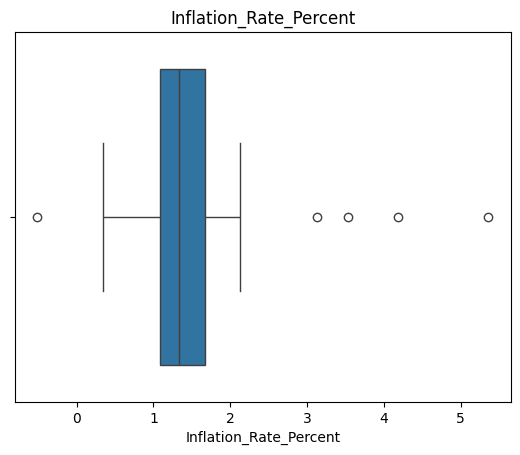

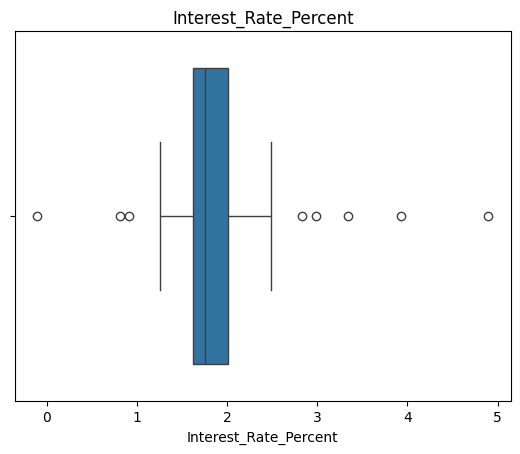

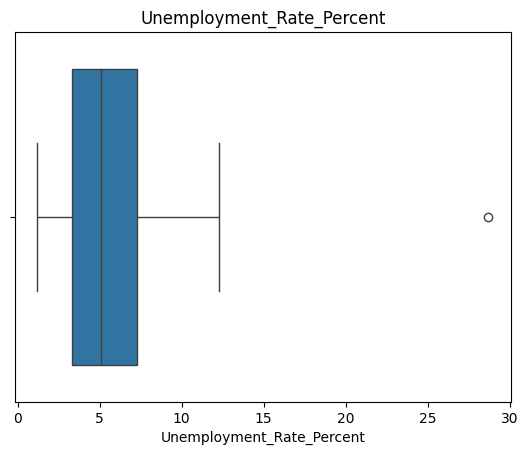

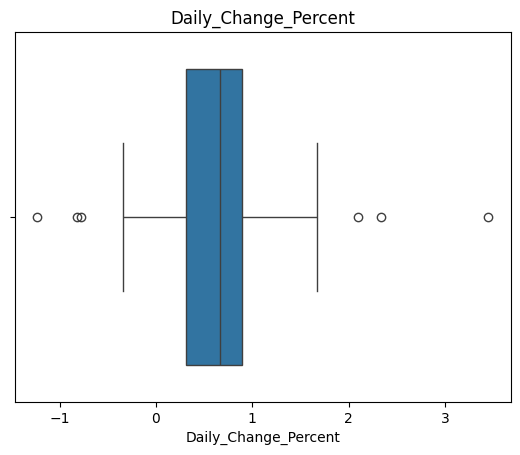

In [111]:
for col in df.select_dtypes(include='number').columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [113]:
# log transform for Inflation and Interest Rate to reduce the skewness and stabilize variance

df["Inflation_Rate_Percent"] = np.log1p(df["Inflation_Rate_Percent"])
df["Interest_Rate_Percent"] = np.log1p(df["Interest_Rate_Percent"])

In [39]:
# Separate features and target
features = [
    "Country",
    "GDP_Growth_Rate_Percent",
    "Inflation_Rate_Percent",
    "Interest_Rate_Percent",
    "Unemployment_Rate_Percent"
]

target = "Daily_Change_Percent"

X = df[features]
y = df[target]
# encode country as scaling only works on numbers
X = pd.get_dummies(X, columns=["Country"], drop_first=True)

# Scale
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)


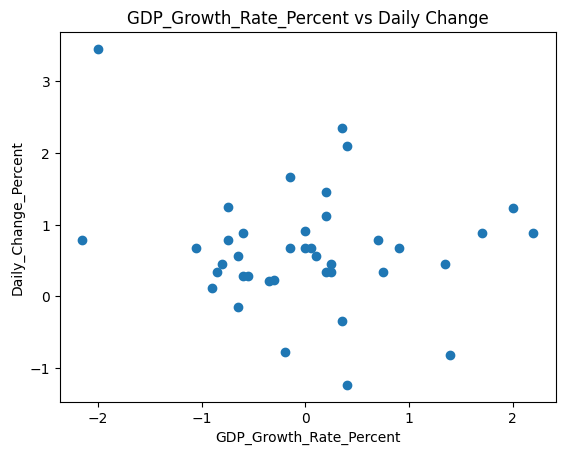

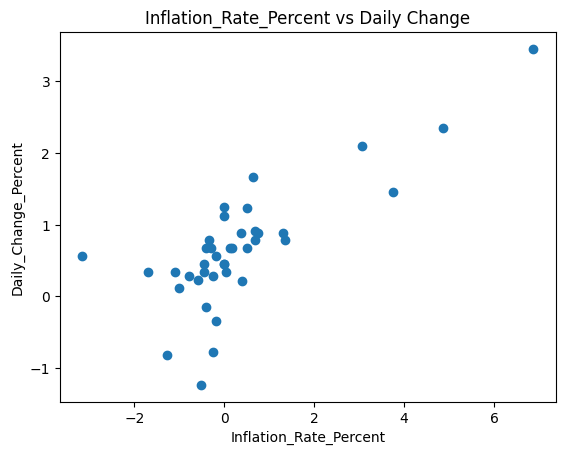

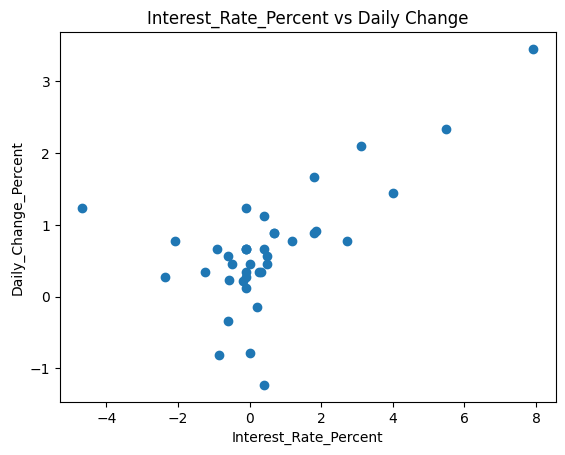

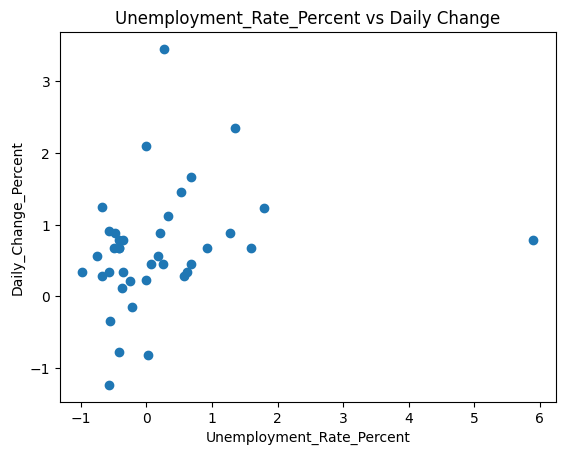

In [115]:
# Visualize distributions after scaling 

for col in X_scaled.columns:
    if col.startswith("Country_"):
        continue  # skip dummy variables
    
    plt.figure()
    plt.scatter(X_scaled[col], y)
    plt.xlabel(col)
    plt.ylabel("Daily_Change_Percent")
    plt.title(f"{col} vs Daily Change")
    plt.show()


In [44]:
# Create mask: keep rows where ALL values <= 4
mask = (X_scaled[X_scaled.select_dtypes(include="number").columns] <= 4).all(axis=1)

# Apply filtering
X_scaled_clean = X_scaled[mask]
y_clean = y[mask]

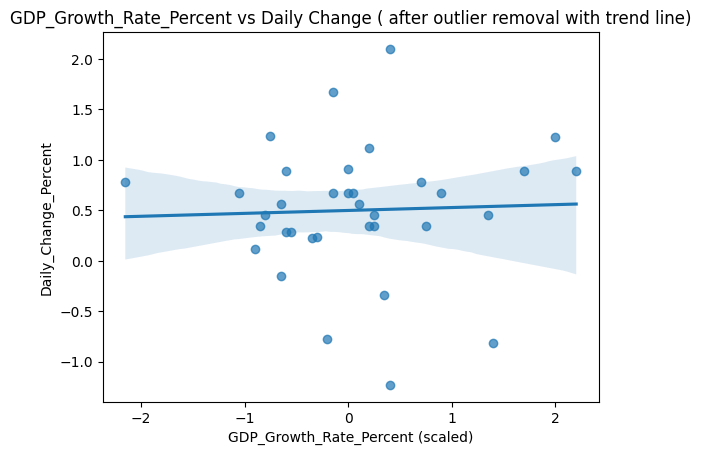

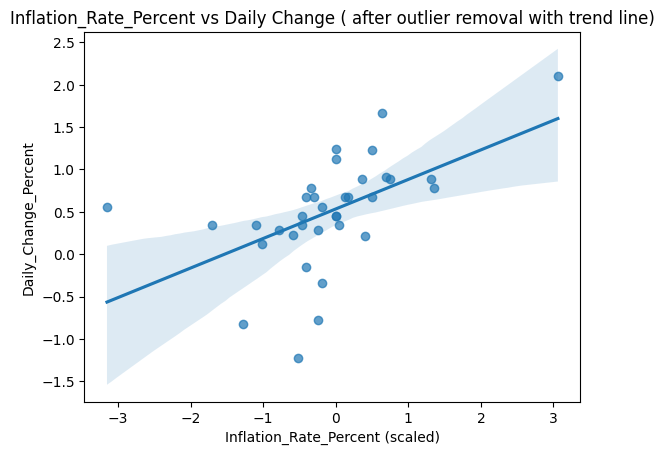

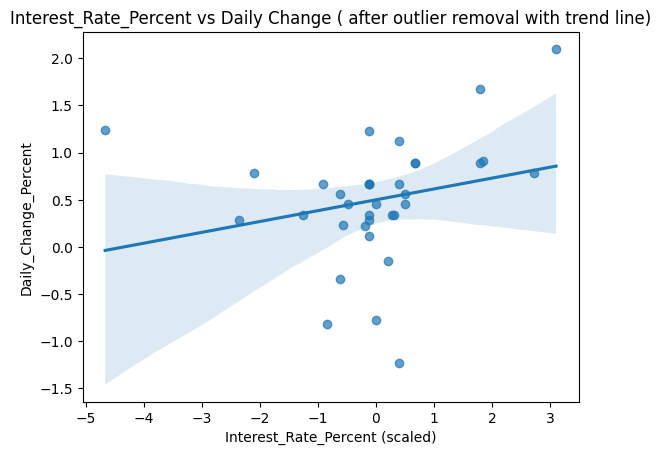

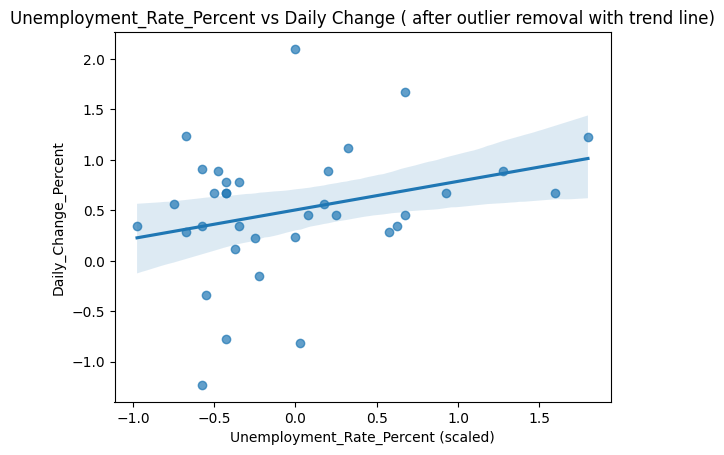

In [46]:
for col in features:
    plt.figure()
    sns.regplot(
        x=X_scaled_clean[col],
        y=y_clean,
        scatter_kws={"alpha": 0.7}
    )
    plt.xlabel(f"{col} (scaled)")
    plt.ylabel("Daily_Change_Percent")
    plt.title(f"{col} vs Daily Change ( after outlier removal with trend line)")
    plt.show()

##### Observations
1. GDP Growth → Daily Change
- Trend line is almost flat (slightly positive)
- Points are widely scattered
-> Very weak relationship
2. Inflation Rate → Daily Change
- Clear upward slope
- Points somewhat aligned with the trend line
-> Moderate positive relationship
3. Interest Rate → Daily Change
- Slight upward slope
- But very wide spread
-> Weak-to-moderate relationship
4. Unemployment Rate → Daily Change
-Clear upward trend
- Points relatively more structured than others
-> Moderate positive relationship

! The relationship between predictors (X) and target (y) is linear -> Fullfill OLS linearity 

#### Correlation

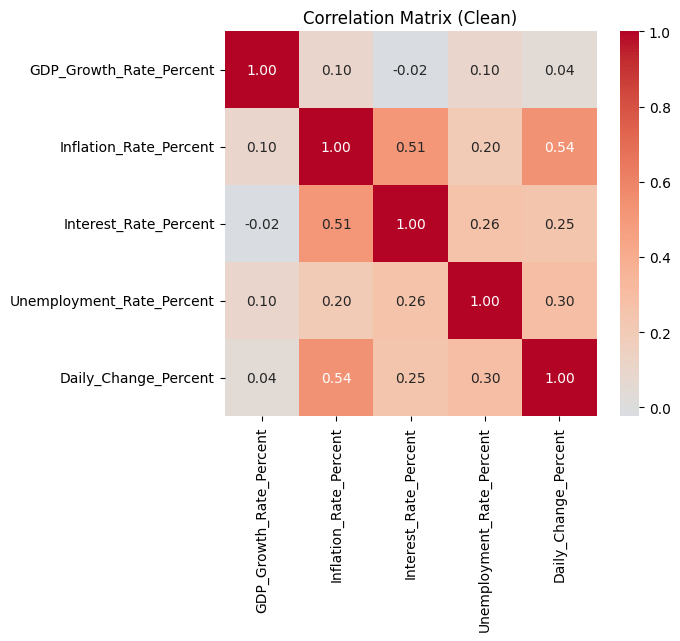

In [112]:
# Combine X and y for correlation
df_corr = X_scaled_clean.copy()
df_corr["Daily_Change_Percent"] = y_clean

df_corr = pd.concat([X_scaled_clean[features], y_clean], axis=1)

plt.figure(figsize=(6,5))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix (Clean)")
plt.show()

In [53]:
# Correlation with the target
corr_target = df_corr.corr()[target].sort_values(ascending=False)
print(corr_target)

Daily_Change_Percent         1.000000
Inflation_Rate_Percent       0.536907
Unemployment_Rate_Percent    0.295268
Interest_Rate_Percent        0.245588
GDP_Growth_Rate_Percent      0.040697
Name: Daily_Change_Percent, dtype: float64


!! OBSERVATION

1. Inflation (0.54)
- Strongest predictor
- Clear positive relationship

2. Unemployment (0.30) & Interest Rate (0.25)
- Some influence, but not strong

3. GDP Growth (0.04) --> Probably no relationship

!! Multicollinearity check
- Corelation between Inflation and Interest Rate = 0.51 -> doesn't reach the 0.7 threshold, therefore not critical, but could slightly affect OLS coefficients -> model will likely have moderate predictive power only

### Split datas

In [ ]:
test_size: float = 0.2
random_state: int = 42

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_clean,
    y_clean,
    test_size=test_size,
    random_state=random_state
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (31, 42)
X_test: (4, 42)
y_train: (31,)
y_test: (4,)


### Regression

Our regression model:
$$
Y = \beta_0 + \beta_1 (\text{GDP Growth}) + \beta_2 (\text{Inflation}) + \beta_3 (\text{Interest Rate}) + \beta_4 (\text{Unemployment}) + \varepsilon
$$

In [ ]:
# Linear Regression -> linear relationship between predictors and the target

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
# Random forest regression -> whether combining multiple trees improves predictive performance and captures more complex relationships.
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=3,
    random_state=42
)

rf.fit(X_train, y_train)
# Make predictions
y_pred_rf = rf.predict(X_test)

In [ ]:
# Decision Tree -> explore whether nonlinear patterns exist between macroeconomic variables and daily changes.
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [ ]:
# Ridge Regression -> linear regression with L2 regularization, handles multicollinearity between predictors
# test whether adding regularization improves model stability and performance.
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [ ]:
# Lasso -> Uses L1 regularization
# Performs automatic feature selection aka shrinks some coefficients to zero
# identify the most relevant predictors and reduce the impact of weak variables.
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

In [79]:
results = []
def evaluate(name, y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse
    })

# Evaluate models
evaluate("Linear", y_test, y_pred_lr)
evaluate("Ridge", y_test, y_pred_ridge)
evaluate("Lasso", y_test, y_pred_lasso)
evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("Random Forest", y_test, y_pred_rf)

# Convert to DataFrame
results_df = pd.DataFrame(results)
results_df

,Model,R2,RMSE
0,Linear,-0.031168,0.803966
1,Ridge,-0.040635,0.807649
2,Lasso,-0.139205,0.845034
3,Decision Tree,0.006435,0.789172
4,Random Forest,-0.033599,0.804913


# OBSERVATION
All models perform poorly
R² ≈ 0 or negative for all models
- The Decision Tree model is the only model with positive coefficient of determination, however, it shows zero explanatory power.
- The predictors do not contain enough information to explain the target

#### Unsupervised learning

##### KMeans

In [83]:
from sklearn.cluster import KMeans

# Use features only (no target)
X_unsup = X_scaled_clean.copy()

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_unsup)

# Add cluster labels
df_clustered = X_unsup.copy()
df_clustered["Cluster"] = clusters

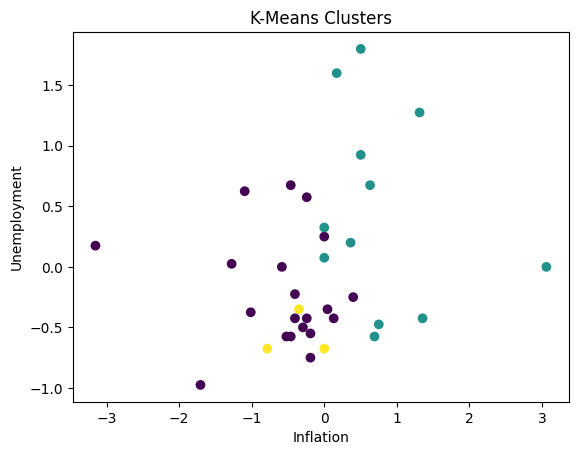

In [97]:
# Visualize clusters
plt.scatter(
    X_unsup["Inflation_Rate_Percent"],
    X_unsup["Unemployment_Rate_Percent"],
    c=clusters
)

plt.xlabel("Inflation")
plt.ylabel("Unemployment")
plt.title("K-Means Clusters")
plt.show()

In [102]:
cluster_result = df_clustered.groupby("Cluster").mean()

cluster_result = cluster_result.T
cluster_result_clean = cluster_result[~cluster_result.index.str.startswith("Country_")]

cluster_result_clean

Cluster,0,1,2
GDP_Growth_Rate_Percent,-0.092500,0.416667,-0.216667
Inflation_Rate_Percent,-0.583246,0.778818,-0.377638
Interest_Rate_Percent,-0.217254,1.141690,-3.042117
Unemployment_Rate_Percent,-0.203750,0.450000,-0.566667


!!! Observation
1. Cluster 0
- GDP: -0.09 → average
- Inflation: -0.58 → low
- Interest: -0.22 → low
- Unemployment: -0.20 → low

--> Economically stable, low-pressure environments

2. Cluster 1
- GDP: +0.42 → higher growth
- Inflation: +0.78 → high
- Interest: +1.14 → very high
- Unemployment: +0.45 → higher

--> Economies under macroeconomic stress

3. Cluster 2
- GDP: -0.22 → low
- Inflation: -0.38 → low
- Interest: -3.04 🚨 → extremely low
- Unemployment: -0.57 → low
--> Economies with very loose monetary policy / weak demand

---> Clusters differ strongly in Interest + Inflation

##### PCA

In [86]:
# PCA (Principal Component Analysis)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_clean)


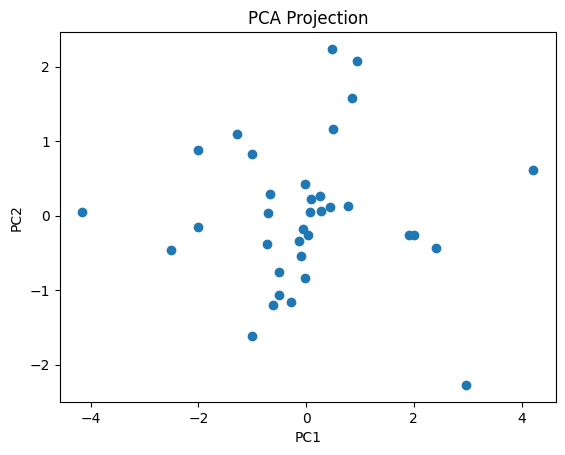

In [87]:
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

In [95]:
# Explained variance
print("Explained variance:", pca.explained_variance_ratio_)
# Interpreting CPA
# Create DataFrame
pca_df = pd.DataFrame(
    pca.components_,
    columns=X_unsup.columns,
    index=["PC1", "PC2"]
)

# Transpose → PCs become columns → easier to read
pca_df = pca_df.T
pca_df_clean = pca_df[~pca_df.index.str.startswith("Country_")]

pca_df_clean

Explained variance: [0.455833   0.17378697]


,PC1,PC2
GDP_Growth_Rate_Percent,0.015971,0.920745
Inflation_Rate_Percent,0.468833,0.270467
Interest_Rate_Percent,0.863725,-0.183260
Unemployment_Rate_Percent,0.146814,0.114272


!!! OBSERVATION
1. PC1
- GDP: 0.016 → negligible
- Inflation: 0.469 → important
- Interest Rate: 0.864 → dominant
- Unemployment: 0.147 → small
-> PC1 is mainly about Interest Rate + Inflation --> captures monetary pressure / inflation environment

2. PC2
- GDP: 0.921 → dominant
- Inflation: 0.270 → moderate
- Interest Rate: -0.183 → moderate negative
- Unemployment: 0.114 → small
--> CP2 separates high-growth vs low-growth economies

!! Insight
- the primary source of variation in the data is driven by interest rates and inflation
- the second component is largely associated with GDP growth.
- PC1 = Interest + Inflation --> consistent with the finding in KMEANS

!!! Dataset has clear structure and is driven by meaningful variables.

### CONCLUSION

Although clustering and PCA reveal clear structure in the macroeconomic variables, this structure does not translate into predictive power for daily changes. This suggests that while macroeconomic indicators differentiate economic regimes, they are insufficient to explain short-term fluctuations of the daily index changes, which are likely driven by additional factors not captured in the dataset.

This can be explained by several factors. First, the target variable represents short-term (daily) changes, which are inherently volatile and influenced by many external factors such as market sentiment, news events, and shocks that are not included in the dataset. 

Second, the explanatory variables are macroeconomic indicators, which typically evolve slowly over time and are better suited for explaining long-term trends rather than short-term fluctuations. 

Finally, the relatively small sample size further limits the ability of models to learn robust patterns.

The analysis shows that while macroeconomic variables exhibit clear structure and meaningful relationships among themselves, they have limited ability to predict daily changes in the target variable. Among the tested models, no approach demonstrated satisfactory predictive performance, indicating that the selected features are insufficient for accurate forecasting in this context.